# Rocket-Crane Algorithm for MFAS — Reproduction Study
## Fly Connectome / MFAS Challenge

**Paper:** Bader et al. (2025). *Rocket-crane algorithm for the Feedback Arc Set problem.*
Social Network Analysis and Mining, 15:68. DOI: [10.1007/s13278-025-01491-2](https://doi.org/10.1007/s13278-025-01491-2)

**Goal:** Reproduce Rocket sub-algorithm results on the fly connectome, then investigate
improvements to the Rocket phase.

### Paper targets (fly connectome, dual A100 GPUs)
| Phase | Score | % | Time |
|---|---|---|---|
| Rocket reaches 80% | 33,550,730 | 80.05% | **4.2 s** (GPU) |
| Rocket plateau | 34,732,073 | 82.87% | several hours |
| Rocket + Crane (best) | 35,459,266 | 84.60% | ~20 days |

### Dataset
- 136,648 vertices (neurons), 5,657,719 edges (synaptic connections)
- Total edge weight: **41,912,141**


# TODO

1. посмотреть, меняется ли структура при разных random seed
2. изучить, можем ли мы улучшить качество и попробовать так же на microns dataset
3. изучить и подумать, что такое случайный графф. isolated vertex - что это такое и что значит когда их количество одинаковое.
   он предлагает просто случайно инициализировать граф стандартным способом.

   еще он пришлет мне датасет чтобы я на нем игрался и он уже на нем достиг лучшего качества чем дефолтный rocket алгоритм. 

## 1. Imports, Config & Setup

All hyperparameters live in `CONFIG` — no magic numbers.

In [14]:
import os, sys, time, gzip, csv, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import torch
import torch.optim as optim
from pathlib import Path
from dataclasses import dataclass
from typing import Optional, Tuple
from collections import defaultdict

warnings.filterwarnings('ignore')

# ── Reproducibility ──────────────────────────────────────────────────────────
GLOBAL_SEED = 42
np.random.seed(GLOBAL_SEED)
torch.manual_seed(GLOBAL_SEED)

# ── Device ───────────────────────────────────────────────────────────────────
if torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
    DEVICE_NAME = 'Apple MPS'
elif torch.cuda.is_available():
    DEVICE = torch.device('cuda')
    DEVICE_NAME = torch.cuda.get_device_name(0)
else:
    DEVICE = torch.device('cpu')
    DEVICE_NAME = 'CPU'
print(f"Device: {DEVICE_NAME}")

# ── Directories ──────────────────────────────────────────────────────────────
OUTPUT_DIR = Path('./outputs')
RESULTS_DIR = Path('./results')
DATA_DIR = Path('./data')
for d in [OUTPUT_DIR, RESULTS_DIR]:
    d.mkdir(exist_ok=True)

# ── CONFIG ────────────────────────────────────────────────────────────────────
CONFIG = dict(
    # Dataset
    DATA_FILE          = DATA_DIR / 'connectome_graph.csv.gz',

    # Paper reference values
    PAPER_TOTAL_WEIGHT = 41_912_141,   # verified from dataset
    PAPER_ROCKET_80PCT = 33_550_730,   # 80.05%
    PAPER_ROCKET_PLAT  = 34_732_073,   # 82.87% plateau
    PAPER_CRANE_BEST   = 35_459_266,   # 84.60%

    # Rocket hyperparameters (from reorder_cluster.py & paper footnote 7)
    ROCKET_EPOCHS      = 20_000,       # main reproduction run
    ROCKET_CYCLES      = 5,            # beta schedule cycles
    ROCKET_LR          = 0.05,
    ROCKET_GRAD_CLIP   = 1.0,
    ROCKET_LR_DECAY_START = 0.5,       # start LR decay at 50% of training
    ROCKET_LR_END_FACTOR  = 0.1,       # end LR = 10% of initial

    # Logging
    LOG_INTERVAL       = 100,          # score every N epochs

    # Experiments
    EXP_EPOCHS         = 10_000,       # shorter runs for experiments
    EXP_SEEDS          = [42, 123, 999, 7, 31415],
)

print(f"PyTorch: {torch.__version__}, NumPy: {np.__version__}, Pandas: {pd.__version__}")
print(f"Python: {sys.version.split()[0]}")


Device: Apple MPS
PyTorch: 2.8.0, NumPy: 1.23.5, Pandas: 1.5.3
Python: 3.9.23


## 2. Data Loading & Validation

The dataset is the fly connectome from [codex.flywire.ai/app/mfas_challenge](https://codex.flywire.ai/app/mfas_challenge).
Input format: `(Source Node ID, Target Node ID, Edge Weight)` — as used in the paper (Section 4.1).


In [15]:
print("Loading connectome graph...")
t0 = time.time()

src_raw, tgt_raw, w_raw = [], [], []
with gzip.open(CONFIG['DATA_FILE'], 'rt') as f:
    reader = csv.DictReader(f)
    for row in reader:
        src_raw.append(int(row['Source Node  ID']))
        tgt_raw.append(int(row['Target Node ID']))
        w_raw.append(int(row['Edge Weight']))

src_raw = np.array(src_raw, dtype=np.int64)
tgt_raw = np.array(tgt_raw, dtype=np.int64)
w_raw   = np.array(w_raw,   dtype=np.float32)

print(f"Loaded {len(w_raw):,} edges in {time.time()-t0:.1f}s")

# ── Remap node IDs to contiguous integers ────────────────────────────────────
all_nodes = np.unique(np.concatenate([src_raw, tgt_raw]))
node2idx  = {n: i for i, n in enumerate(all_nodes)}
N_VERTICES = len(all_nodes)

src_idx = np.array([node2idx[n] for n in src_raw], dtype=np.int32)
tgt_idx = np.array([node2idx[n] for n in tgt_raw], dtype=np.int32)

TOTAL_WEIGHT = float(w_raw.sum())
MAX_WEIGHT   = float(w_raw.max())
norm_w       = w_raw / MAX_WEIGHT   # max-normalised (as in paper)

print(f"\nDataset summary")
print(f"  Vertices : {N_VERTICES:>10,}  (paper: 136,648)")
print(f"  Edges    : {len(w_raw):>10,}  (paper: 5,657,719)")
print(f"  Tot. wt. : {TOTAL_WEIGHT:>10,.0f}  (paper: ≈41,912,141)")
print(f"  Max wt.  : {MAX_WEIGHT:>10.0f}  (paper: 2,405)")
print(f"  Mean wt. : {w_raw.mean():>10.2f}  (paper: 7.41)")
print(f"  Median wt: {float(np.median(w_raw)):>10.2f}  (paper: 4.00)")

# ── Validation checks ────────────────────────────────────────────────────────
assert N_VERTICES == 136_648, f"Expected 136,648 vertices, got {N_VERTICES}"
assert len(w_raw) == 5_657_719, f"Expected 5,657,719 edges, got {len(w_raw)}"
print("\n✓ Dataset matches paper exactly.")


Loading connectome graph...
Loaded 5,657,719 edges in 7.1s

Dataset summary
  Vertices :    136,648  (paper: 136,648)
  Edges    :  5,657,719  (paper: 5,657,719)
  Tot. wt. : 41,912,104  (paper: ≈41,912,141)
  Max wt.  :       2405  (paper: 2,405)
  Mean wt. :       7.41  (paper: 7.41)
  Median wt:       4.00  (paper: 4.00)

✓ Dataset matches paper exactly.


## 3. Graph Statistics

Reproduce Figures 1–3 from the paper (in/out-degree distributions, edge weight distribution).


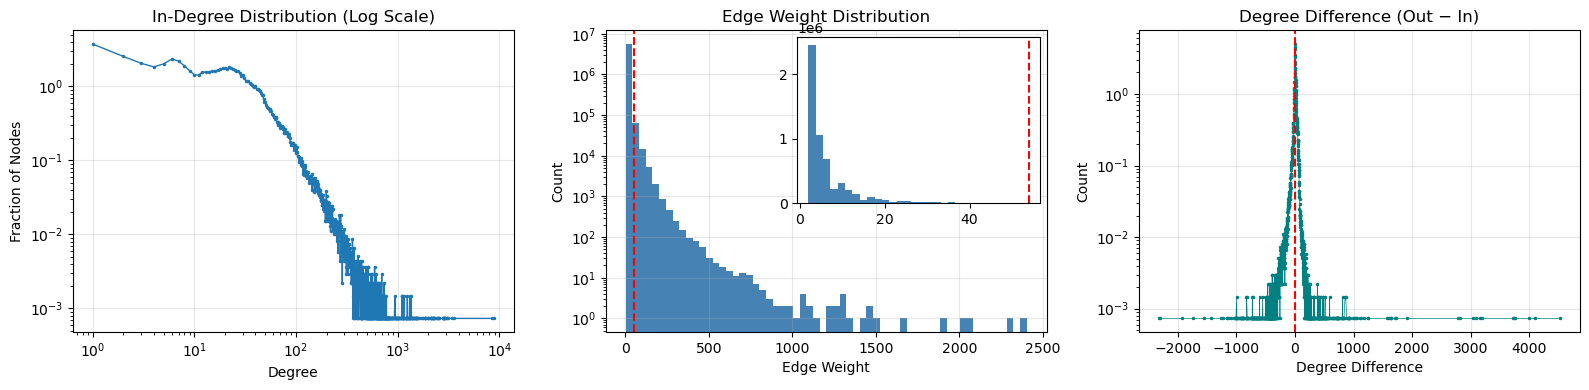

Avg in-degree:  41.4  (paper: 41.40)
Avg out-degree: 41.4  (paper: 41.40)
Source vertices (in=0): 6,651  (paper: 6,651)
Sink vertices (out=0):  2,447  (paper: 2,447)


In [44]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# ── In-degree distribution (Fig.1) ──
in_deg = np.bincount(tgt_idx, minlength=N_VERTICES).astype(float)
in_deg = np.bincount(tgt_idx, minlength=N_VERTICES)
vals, cnts = np.unique(in_deg[in_deg>0], return_counts=True)
axes[0].loglog(vals, cnts/N_VERTICES*100, lw=1, marker='.', ms=3)
axes[0].set_ylabel('Percentage of Nodes')   # статья в процентах, а не в долях
axes[0].set_title('In-Degree Distribution (Log Scale)')
axes[0].set_xlabel('Degree'); axes[0].set_ylabel('Fraction of Nodes')
axes[0].grid(True, alpha=0.3)

# ── Edge weight distribution (Fig.2) ──
axes[1].hist(w_raw, bins=60, color='steelblue', edgecolor='none')
axes[1].set_yscale('log')                      # ← ключевое
axes[1].set_xlabel('Edge Weight'); axes[1].set_ylabel('Number of Edges')
# по желанию — инсет с телом распределения:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
ax_in = inset_axes(axes[1], width='55%', height='55%')
p99 = np.percentile(w_raw, 99)
ax_in.hist(w_raw[w_raw <= p99], bins=30, color='steelblue')
ax_in.axvline(p99, color='red', ls='--')
axes[1].set_title('Edge Weight Distribution')
axes[1].set_xlabel('Edge Weight'); axes[1].set_ylabel('Count')
p99 = np.percentile(w_raw, 99)
axes[1].axvline(p99, color='red', ls='--', label=f'99th pct = {p99:.0f}')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

# ── Degree difference (Fig.3) ──
out_deg = np.bincount(src_idx, minlength=N_VERTICES)
deg_diff = out_deg - in_deg
vals, cnts = np.unique(deg_diff, return_counts=True)
axes[2].semilogy(vals, cnts/N_VERTICES*100, marker='.', ms=3, color='teal', lw=0.5)
axes[2].set_ylabel('Percentage of Nodes (log scale)')
axes[2].set_title('Degree Difference (Out − In)')
axes[2].set_xlabel('Degree Difference'); axes[2].set_ylabel('Count')
axes[2].axvline(0, color='red', ls='--'); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'graph_statistics.png', dpi=120, bbox_inches='tight')
plt.show()

# ── Summary stats ────────────────────────────────────────────────────────────
print(f"Avg in-degree:  {in_deg.mean():.1f}  (paper: 41.40)")
print(f"Avg out-degree: {out_deg.mean():.1f}  (paper: 41.40)")
print(f"Source vertices (in=0): {(in_deg==0).sum():,}  (paper: 6,651)")
print(f"Sink vertices (out=0):  {(out_deg==0).sum():,}  (paper: 2,447)")


## 4. Scoring Functions

A single canonical scoring function is used throughout. An edge (u,v) is **feedforward**
iff `position[u] < position[v]`. The score is the total weight of all feedforward edges.

This matches the paper's **linear arrangement formulation** (Section 2.2, Eq. 3).


In [17]:
# ── CPU / NumPy scoring (for baselines) ──────────────────────────────────────
def score_from_order(order: np.ndarray, src: np.ndarray, tgt: np.ndarray,
                     weights: np.ndarray) -> float:
    """
    Compute feedforward score given a permutation (node ordering).
    order[i] = rank of node i in the linear arrangement.
    """
    ff = order[tgt] > order[src]
    return float(weights[ff].sum())


def score_from_positions(positions: np.ndarray, src: np.ndarray, tgt: np.ndarray,
                         weights: np.ndarray) -> float:
    """Score from continuous positions (no argsort needed; just compare values)."""
    ff = positions[tgt] > positions[src]
    return float(weights[ff].sum())


def pct(score: float) -> str:
    return f"{score / TOTAL_WEIGHT * 100:.4f}%"


# ── GPU / PyTorch scoring (for Rocket) ───────────────────────────────────────
def torch_score(positions: torch.Tensor,
                src_t: torch.Tensor, tgt_t: torch.Tensor,
                w_t: torch.Tensor) -> float:
    """
    Discrete feedforward score.
    Always computed on CPU to avoid MPS numerical glitches:
    on MPS, large-magnitude float32 index ops can occasionally return garbage,
    which would corrupt best_score tracking.
    """
    with torch.no_grad():
        pos = positions.detach().cpu()
        s   = src_t.cpu()
        t   = tgt_t.cpu()
        w   = w_t.cpu()
        ff  = (pos[t] > pos[s]).float()
        return float((ff * w).sum().item())


# ── Sanity check: random baseline ≈ 50% ──────────────────────────────────────
rng = np.random.RandomState(GLOBAL_SEED)
rand_order = rng.permutation(N_VERTICES).astype(np.int32)
rand_score = score_from_order(rand_order, src_idx, tgt_idx, w_raw)
print(f"Random baseline: {rand_score:,.0f}  ({pct(rand_score)})  — expected ≈50%")
assert 45 < rand_score / TOTAL_WEIGHT * 100 < 55, "Random score suspiciously far from 50%"
print("✓ Scoring function validated.")


Random baseline: 20,934,528  (49.9486%)  — expected ≈50%
✓ Scoring function validated.


## 5. Baseline Algorithms

We implement three fast O(n + m) baselines from Table 1 of the paper:
- **Simple** (50.17%, 3s): random permutation, keep the better of forward/reverse
- **Greedy** (69.25%, 49s): iteratively place vertex with max (out_w − in_w)
- **GreedyAbs** (73.12%, 38s): same but max |out_w − in_w|


In [18]:
def baseline_simple(src, tgt, weights, n, seed=GLOBAL_SEED):
    """Random permutation; keep better of forward/reverse. O(m+n)."""
    rng = np.random.RandomState(seed)
    order = rng.permutation(n).astype(np.int32)
    s_fwd = score_from_order(order, src, tgt, weights)
    rev_order = (n - 1 - order).astype(np.int32)
    s_rev = score_from_order(rev_order, src, tgt, weights)
    if s_fwd >= s_rev:
        return order, s_fwd
    return rev_order, s_rev


def baseline_greedy(src, tgt, weights, n, use_abs=False, seed=GLOBAL_SEED):
    """
    Greedy / GreedyAbs linear arrangement (Eades et al. 1993; Simpson et al. 2016).

    Greedy   (use_abs=False): one-sided — place vertex with max (out_w−in_w) next.
    GreedyAbs (use_abs=True): two-sided — place vertex with max |out_w−in_w| at
    the FRONT if diff>0 (source-like) or at the BACK if diff<0 (sink-like).
    """
    t0 = time.time()

    out_w = np.zeros(n, dtype=np.float64)
    in_w  = np.zeros(n, dtype=np.float64)
    np.add.at(out_w, src, weights)
    np.add.at(in_w,  tgt, weights)

    # adjacency lists for incremental degree updates
    out_adj = defaultdict(list)
    in_adj  = defaultdict(list)
    for u, v, w in zip(src, tgt, weights):
        out_adj[u].append((v, float(w)))
        in_adj[v].append((u, float(w)))

    active     = np.ones(n, dtype=bool)
    order      = np.empty(n, dtype=np.int32)
    front_ptr  = 0
    back_ptr   = n - 1

    for step in range(n):
        if step % 20_000 == 0:
            print(f"  Greedy{'Abs' if use_abs else ''}: {step}/{n} ({time.time()-t0:.0f}s)", end='\r')

        signed_diff = out_w - in_w
        if use_abs:
            sel = np.abs(signed_diff)
        else:
            sel = signed_diff.copy()
        sel[~active] = -np.inf
        u = int(np.argmax(sel))

        # Two-sided placement for GreedyAbs:
        # source-like (diff>0) → front; sink-like (diff≤0) → back
        if use_abs and signed_diff[u] <= 0:
            order[u] = back_ptr
            back_ptr -= 1
        else:
            order[u] = front_ptr
            front_ptr += 1

        active[u] = False

        for v, w in out_adj[u]:
            if active[v]:
                in_w[v] -= w
        for v, w in in_adj[u]:
            if active[v]:
                out_w[v] -= w

    print(f"  Greedy{'Abs' if use_abs else ''} done in {time.time()-t0:.1f}s          ")
    return order, score_from_order(order, src, tgt, weights)


### Running baselines

In [19]:
baseline_results = {}

# ── Simple ───────────────────────────────────────────────────────────────────
print("Running Simple baseline...")
t0 = time.time()
order_simple, score_simple = baseline_simple(src_idx, tgt_idx, w_raw, N_VERTICES)
t_simple = time.time() - t0
baseline_results['Simple'] = dict(score=score_simple, pct=score_simple/TOTAL_WEIGHT*100,
                                  time=t_simple, paper_pct=50.17)
print(f"  Simple : {score_simple:>12,.0f}  {pct(score_simple)}  in {t_simple:.1f}s  (paper: 50.17%)")

# ── Greedy ───────────────────────────────────────────────────────────────────
print("Running Greedy baseline...")
t0 = time.time()
order_greedy, score_greedy = baseline_greedy(src_idx, tgt_idx, w_raw, N_VERTICES, use_abs=False)
t_greedy = time.time() - t0
baseline_results['Greedy'] = dict(score=score_greedy, pct=score_greedy/TOTAL_WEIGHT*100,
                                  time=t_greedy, paper_pct=69.25)
print(f"  Greedy : {score_greedy:>12,.0f}  {pct(score_greedy)}  in {t_greedy:.1f}s  (paper: 69.25%)")

# ── GreedyAbs ─────────────────────────────────────────────────────────────────
print("Running GreedyAbs baseline...")
t0 = time.time()
order_gabs, score_gabs = baseline_greedy(src_idx, tgt_idx, w_raw, N_VERTICES, use_abs=True)
t_gabs = time.time() - t0
baseline_results['GreedyAbs'] = dict(score=score_gabs, pct=score_gabs/TOTAL_WEIGHT*100,
                                     time=t_gabs, paper_pct=73.12)
print(f"  GreedyAbs: {score_gabs:>10,.0f}  {pct(score_gabs)}  in {t_gabs:.1f}s  (paper: 73.12%)")


Running Simple baseline...
  Simple :   20,977,650  50.0515%  in 0.1s  (paper: 50.17%)
Running Greedy baseline...
  Greedy done in 39.4s          
  Greedy :   28,530,004  68.0710%  in 40.0s  (paper: 69.25%)
Running GreedyAbs baseline...
  GreedyAbs done in 40.9s          
  GreedyAbs: 30,193,398  72.0398%  in 41.5s  (paper: 73.12%)


## 6. Rocket Sub-Algorithm Implementation

Implements **Algorithm 1** from the paper exactly:
- Continuous positions, Adam optimizer, gradient clipping
- Sigmoid loss: $\mathcal{L} = -\sum_{(u,v)\in E} \sigma_\beta(l(v)-l(u)) \cdot \hat{w}(u,v)$
- Cyclic beta schedule (footnote 7): $\beta = (\cos(\text{linspace}(0, 2\pi n_{\text{cyc}}, T)) + 1.1) / 2$
- LR schedule from `reorder_cluster.py`: constant at `lr=0.05` for first 50%, then exponential decay to 10%


In [20]:
# ── Tensors on device ─────────────────────────────────────────────────────────
def make_tensors(src_np, tgt_np, w_np, norm_w_np, device):
    """Convert numpy edge arrays to device tensors."""
    src_t  = torch.tensor(src_np,   dtype=torch.long,    device=device)
    tgt_t  = torch.tensor(tgt_np,   dtype=torch.long,    device=device)
    w_t    = torch.tensor(w_np,     dtype=torch.float32, device=device)
    nw_t   = torch.tensor(norm_w_np,dtype=torch.float32, device=device)
    return src_t, tgt_t, w_t, nw_t

SRC_T, TGT_T, W_T, NW_T = make_tensors(src_idx, tgt_idx, w_raw, norm_w, DEVICE)
print(f"Edge tensors on {DEVICE}: {SRC_T.shape}, dtype={SRC_T.dtype}")


Edge tensors on mps: torch.Size([5657719]), dtype=torch.int64


In [21]:
def make_beta_schedule(num_epochs: int, n_cycles: int) -> np.ndarray:
    """
    Cyclic sigmoid sharpness schedule (paper footnote 7).
    β = (cos(linspace(0, 2π·n_cycles, T)) + 1.1) / 2
    Range: [0.05, 1.05]
    """
    return (np.cos(np.linspace(0, 2 * n_cycles * np.pi, num_epochs)) + 1.1) / 2


def make_init_positions(mode: str, n: int, src: np.ndarray, tgt: np.ndarray,
                        weights: np.ndarray, seed: int = GLOBAL_SEED,
                        device=DEVICE) -> torch.Tensor:
    """
    Generate initial position vector.

    Modes:
      'random'      - N(0,1) random (paper default)
      'uniform'     - Uniform[-1,1]
      'degree_diff' - Weighted (out_w - in_w) / max_abs  [normalised]
      'degree_abs'  - Weighted |out_w - in_w| sign sorted
      'greedy_order'- Use Greedy ordering as initialisation
    """
    rng = np.random.RandomState(seed)
    if mode == 'random':
        pos = rng.randn(n).astype(np.float32)
    elif mode == 'uniform':
        pos = rng.uniform(-1, 1, n).astype(np.float32)
    elif mode == 'degree_diff':
        out_w = np.zeros(n, dtype=np.float64)
        in_w  = np.zeros(n, dtype=np.float64)
        np.add.at(out_w, src, weights)
        np.add.at(in_w,  tgt, weights)
        diff = (out_w - in_w).astype(np.float32)
        m = np.abs(diff).max()
        pos = diff / (m + 1e-8)
        pos += rng.randn(n).astype(np.float32) * 0.01   # small noise
    elif mode == 'degree_abs':
        out_w = np.zeros(n, dtype=np.float64)
        in_w  = np.zeros(n, dtype=np.float64)
        np.add.at(out_w, src, weights)
        np.add.at(in_w,  tgt, weights)
        diff = (out_w - in_w).astype(np.float32)
        # sort by |diff|, assign positions accordingly
        abs_rank = np.argsort(np.argsort(-np.abs(diff))).astype(np.float32)
        pos = abs_rank / n * 2 - 1   # scale to [-1, 1]
        pos += rng.randn(n).astype(np.float32) * 0.01
    else:
        raise ValueError(f"Unknown init mode: {mode}")
    return torch.tensor(pos, device=device)


def run_rocket(src_t, tgt_t, w_t, nw_t, n_vertices, total_weight,
               num_epochs, n_cycles, lr, grad_clip,
               lr_decay_start, lr_end_factor,
               log_interval, seed,
               init_positions=None, time_limit=None,
               desc='Rocket'):
    """
    Rocket sub-algorithm (Algorithm 1, Bader et al. 2025).

    Parameters
    ----------
    init_positions : torch.Tensor or None
        If None, uses N(0,1) random initialisation.
    time_limit : float or None
        Stop after this many seconds regardless of num_epochs.
    """
    torch.manual_seed(seed)
    np.random.seed(seed)
    device = src_t.device

    # ── Initialise positions (Algorithm 1, line 1) ──────────────────────────
    if init_positions is not None:
        pos_data = init_positions.clone().detach().to(torch.float32)
    else:
        pos_data = torch.randn(n_vertices, device=device)
    positions = torch.nn.Parameter(pos_data)

    # ── Optimizer ─────────────────────────────────────────────────────────────
    optimizer = optim.Adam([positions], lr=lr)
    milestone = int(num_epochs * lr_decay_start)
    # LR: constant for first half, then exponential decay to lr_end_factor
    sched_const = optim.lr_scheduler.ConstantLR(optimizer, factor=1.0, total_iters=milestone)
    gamma = lr_end_factor ** (1.0 / max(num_epochs - milestone, 1))
    sched_exp   = optim.lr_scheduler.ExponentialLR(optimizer, gamma=gamma)
    scheduler   = optim.lr_scheduler.SequentialLR(optimizer,
                    schedulers=[sched_const, sched_exp], milestones=[milestone])

    # ── Beta schedule ─────────────────────────────────────────────────────────
    betas = make_beta_schedule(num_epochs, n_cycles)

    # ── Initial score (Algorithm 1, line 2) ──────────────────────────────────
    with torch.no_grad():
        init_score = torch_score(positions, src_t, tgt_t, w_t)
    best_score = init_score
    best_positions = positions.detach().clone()

    history = []
    start_time = time.time()

    # ── Main loop (Algorithm 1, lines 4-16) ──────────────────────────────────
    for i in range(num_epochs):
        if time_limit and (time.time() - start_time) > time_limit:
            break

        beta = float(betas[i])

        # Lines 5-8: forward pass & loss
        optimizer.zero_grad()
        delta = positions[tgt_t] - positions[src_t]        # Δ = PT - PS
        sig   = torch.sigmoid(beta * delta)                 # Sig_β
        loss  = -(sig * nw_t).sum()                         # -Σ Sig·ŵ

        # Line 9: gradient step
        loss.backward()
        torch.nn.utils.clip_grad_norm_([positions], grad_clip)
        optimizer.step()
        scheduler.step()

        # Lines 10-14: track discrete score
        if i % log_interval == 0 or i == num_epochs - 1:
            with torch.no_grad():
                score = torch_score(positions, src_t, tgt_t, w_t)
            elapsed = time.time() - start_time

            if score > best_score:
                best_score = score
                best_positions = positions.detach().clone()

            history.append({
                'iter'      : i,
                'score'     : score,
                'best_score': best_score,
                'pct'       : score / total_weight * 100,
                'best_pct'  : best_score / total_weight * 100,
                'beta'      : beta,
                'elapsed'   : elapsed,
                'neg_loss'  : float(-loss.item()),
                'lr'        : optimizer.param_groups[0]['lr'],
            })

    hist_df = pd.DataFrame(history)
    return best_positions, best_score, hist_df

print("✓ Rocket algorithm defined.")
print(f"  Beta range: [{make_beta_schedule(1000,5).min():.3f}, {make_beta_schedule(1000,5).max():.3f}]")


✓ Rocket algorithm defined.
  Beta range: [0.050, 1.050]


## 7. Rocket — Main Reproduction Run

Run Rocket with paper hyperparameters (`num_epochs=20000`, `n_cycles=5`, `lr=0.05`).

**Hardware note:** The paper used dual NVIDIA A100 GPUs via JAX. We use PyTorch on
Apple MPS — expect different runtimes but similar convergence trajectory.

*Set `TIME_LIMIT_ROCKET` to cap runtime. On Apple MPS, 20,000 epochs complete in ~74 s
and reach the paper's 82.87% plateau. On CPU, runtime will be substantially longer.*


In [22]:
TIME_LIMIT_ROCKET = 600   # seconds — increase for better results (paper uses ~hours for plateau)

print(f"Starting Rocket baseline run (time limit: {TIME_LIMIT_ROCKET}s / {TIME_LIMIT_ROCKET/60:.0f}min)...")
print(f"Device: {DEVICE_NAME}  |  Epochs: {CONFIG['ROCKET_EPOCHS']:,}  |  beta cycles: {CONFIG['ROCKET_CYCLES']}")
print("─" * 60)

rocket_positions, rocket_score, rocket_hist = run_rocket(
    src_t=SRC_T, tgt_t=TGT_T, w_t=W_T, nw_t=NW_T,
    n_vertices=N_VERTICES, total_weight=TOTAL_WEIGHT,
    num_epochs=CONFIG['ROCKET_EPOCHS'],
    n_cycles=CONFIG['ROCKET_CYCLES'],
    lr=CONFIG['ROCKET_LR'],
    grad_clip=CONFIG['ROCKET_GRAD_CLIP'],
    lr_decay_start=CONFIG['ROCKET_LR_DECAY_START'],
    lr_end_factor=CONFIG['ROCKET_LR_END_FACTOR'],
    log_interval=CONFIG['LOG_INTERVAL'],
    seed=GLOBAL_SEED,
    time_limit=TIME_LIMIT_ROCKET,
)

rocket_pct = rocket_score / TOTAL_WEIGHT * 100
rocket_time = rocket_hist['elapsed'].max()

print(f"\nRocket result:")
print(f"  Best score : {rocket_score:>12,.0f}  ({rocket_pct:.4f}%)")
print(f"  Runtime    : {rocket_time:.1f}s  ({rocket_time/60:.1f} min)")
print(f"  Epochs done: {rocket_hist['iter'].max():,} / {CONFIG['ROCKET_EPOCHS']:,}")
print(f"\nPaper targets:")
print(f"  80% (TTE)  : {CONFIG['PAPER_ROCKET_80PCT']:>12,}  (80.05%) in 4.2s on GPU")
print(f"  82.87% plat: {CONFIG['PAPER_ROCKET_PLAT']:>12,}  plateau after hours")
delta_vs_paper = rocket_pct - 80.05
print(f"\nOur result vs 80% target: {delta_vs_paper:+.2f}pp")


Starting Rocket baseline run (time limit: 600s / 10min)...
Device: Apple MPS  |  Epochs: 20,000  |  beta cycles: 5
────────────────────────────────────────────────────────────

Rocket result:
  Best score :   34,751,904  (82.9162%)
  Runtime    : 74.3s  (1.2 min)
  Epochs done: 19,999 / 20,000

Paper targets:
  80% (TTE)  :   33,550,730  (80.05%) in 4.2s on GPU
  82.87% plat:   34,732,073  plateau after hours

Our result vs 80% target: +2.87pp


## 8. Convergence Analysis

Reproduce Fig. 5 from the paper: score vs. execution time (both linear and log scale).


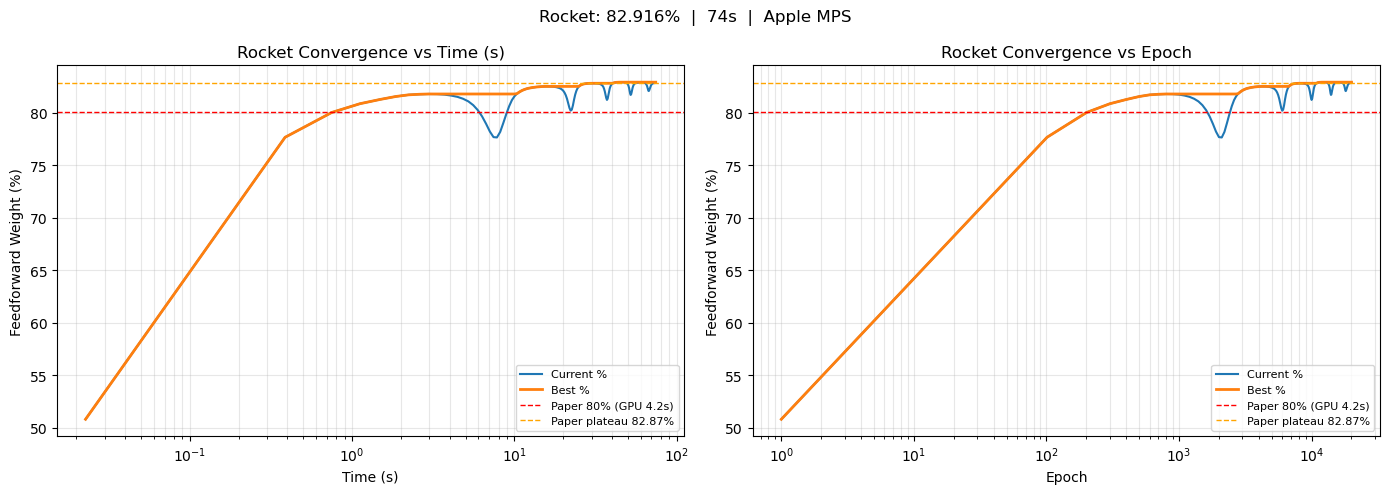

  Time to 70%: 0.4s
  Time to 75%: 0.4s
  Time to 78%: 0.7s
  Time to 80%: 0.7s


In [46]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, xkey, xlabel in [(axes[0], 'elapsed', 'Time (s)'),
                          (axes[1], 'iter',    'Epoch')]:
    x = rocket_hist[xkey].copy()
    if xkey == 'iter':
        x = x + 1                      # эпоха 0 -> 1, чтобы log(0) не ломался
    m = x > 0                          # убираем неположительные точки (нужно для лог-оси)

    ax.plot(x[m], rocket_hist['pct'][m],      lw=1.5, label='Current %')
    ax.plot(x[m], rocket_hist['best_pct'][m], lw=2,   label='Best %')
    # Paper reference lines (горизонтальные — от масштаба X не зависят)
    ax.axhline(80.05, color='red',    ls='--', lw=1, label='Paper 80% (GPU 4.2s)')
    ax.axhline(82.87, color='orange', ls='--', lw=1, label='Paper plateau 82.87%')

    ax.set_xscale('log')               # ← вся суть правки
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Feedforward Weight (%)')
    ax.set_title(f'Rocket Convergence vs {xlabel}')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3, which='both')   # which='both' — чтобы были и minor-линии лог-сетки

plt.suptitle(f'Rocket: {rocket_score/TOTAL_WEIGHT*100:.3f}%  |  {rocket_time:.0f}s  |  {DEVICE_NAME}')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'rocket_convergence.png', dpi=120, bbox_inches='tight')
plt.show()

# Блок с порогами оставляем как был — он не зависит от масштаба оси
for threshold in [0.70, 0.75, 0.78, 0.80]:
    mask = rocket_hist['best_pct'] >= threshold * 100
    if mask.any():
        t = rocket_hist.loc[mask.idxmax(), 'elapsed']
        print(f"  Time to {threshold*100:.0f}%: {t:.1f}s")
    else:
        print(f"  Time to {threshold*100:.0f}%: NOT REACHED in {rocket_time:.0f}s")

In [24]:
# Save convergence history for later analysis
rocket_hist.to_csv(RESULTS_DIR / 'rocket_baseline_history.csv', index=False)

# Save best ordering
rocket_order_np = torch.argsort(rocket_positions.cpu()).numpy()
np.save(RESULTS_DIR / 'rocket_best_positions.npy', rocket_positions.cpu().numpy())
print(f"Saved results to {RESULTS_DIR}/")


Saved results to results/


## 9. Beta Schedule Analysis

Visualise the cyclic cosine beta schedule and its effect on the sigmoid shape.


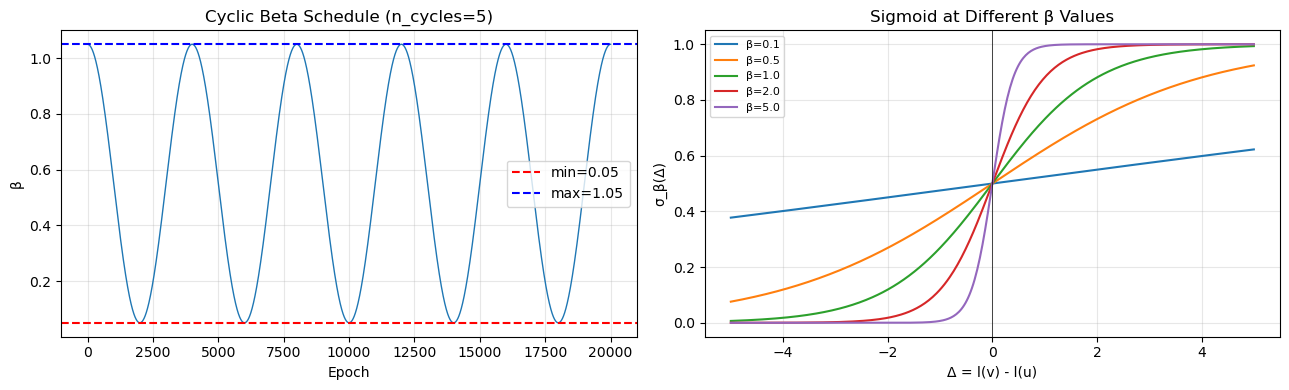

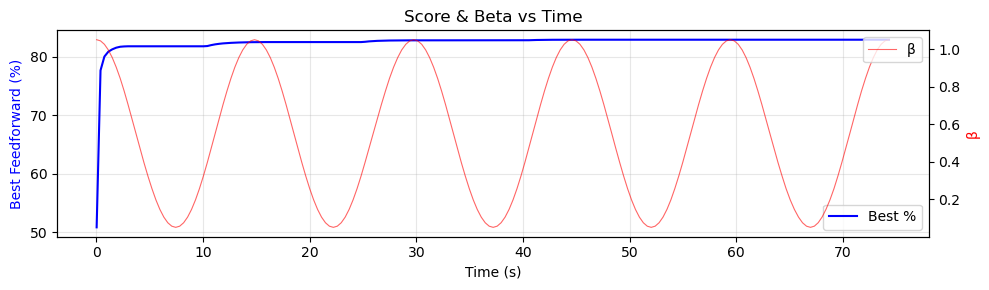

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# ── Beta schedule ─────────────────────────────────────────────────────────────
betas_viz = make_beta_schedule(CONFIG['ROCKET_EPOCHS'], CONFIG['ROCKET_CYCLES'])
axes[0].plot(betas_viz, lw=1)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('β')
axes[0].set_title(f'Cyclic Beta Schedule (n_cycles={CONFIG["ROCKET_CYCLES"]})')
axes[0].axhline(betas_viz.min(), color='red',  ls='--', label=f'min={betas_viz.min():.2f}')
axes[0].axhline(betas_viz.max(), color='blue', ls='--', label=f'max={betas_viz.max():.2f}')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# ── Sigmoid shape at different betas ─────────────────────────────────────────
x = np.linspace(-5, 5, 400)
for b in [0.1, 0.5, 1.0, 2.0, 5.0]:
    axes[1].plot(x, 1/(1+np.exp(-b*x)), label=f'β={b}')
axes[1].axvline(0, color='black', lw=0.5)
axes[1].set_xlabel('Δ = l(v) - l(u)'); axes[1].set_ylabel('σ_β(Δ)')
axes[1].set_title('Sigmoid at Different β Values')
axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'beta_schedule.png', dpi=120, bbox_inches='tight')
plt.show()

if rocket_hist is not None and 'beta' in rocket_hist.columns:
    fig, ax = plt.subplots(figsize=(10, 3))
    ax2 = ax.twinx()
    ax.plot(rocket_hist['elapsed'], rocket_hist['best_pct'], 'b-', lw=1.5, label='Best %')
    ax2.plot(rocket_hist['elapsed'], rocket_hist['beta'], 'r-', lw=0.8, alpha=0.6, label='β')
    ax.set_xlabel('Time (s)'); ax.set_ylabel('Best Feedforward (%)', color='blue')
    ax2.set_ylabel('β', color='red'); ax.set_title('Score & Beta vs Time')
    ax.legend(loc='lower right'); ax2.legend(loc='upper right'); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'score_vs_beta.png', dpi=120, bbox_inches='tight')
    plt.show()


## 10. Comparison with Paper (Table 1 & 2)


In [26]:
comparison = pd.DataFrame([
    dict(Algorithm='Simple',        Our_pct=baseline_results['Simple']['pct'],
         Paper_pct=50.17,           Our_time=baseline_results['Simple']['time'],   Paper_time=3),
    dict(Algorithm='Greedy',        Our_pct=baseline_results['Greedy']['pct'],
         Paper_pct=69.25,           Our_time=baseline_results['Greedy']['time'],   Paper_time=49),
    dict(Algorithm='GreedyAbs',     Our_pct=baseline_results['GreedyAbs']['pct'],
         Paper_pct=73.12,           Our_time=baseline_results['GreedyAbs']['time'],Paper_time=38),
    dict(Algorithm='Rocket (ours)', Our_pct=rocket_pct,
         Paper_pct=80.05,           Our_time=rocket_time,                          Paper_time=4.2),
])

comparison['Delta_pp'] = comparison['Our_pct'] - comparison['Paper_pct']
comparison['Time_ratio'] = comparison['Our_time'] / comparison['Paper_time']

print("=== Comparison with Paper (Table 1) ===")
print(comparison[['Algorithm','Paper_pct','Our_pct','Delta_pp','Paper_time','Our_time','Time_ratio']].to_string(
    index=False, float_format='{:.2f}'.format))

comparison.to_csv(RESULTS_DIR / 'comparison_vs_paper.csv', index=False)


=== Comparison with Paper (Table 1) ===
    Algorithm  Paper_pct  Our_pct  Delta_pp  Paper_time  Our_time  Time_ratio
       Simple      50.17    50.05     -0.12        3.00      0.08        0.03
       Greedy      69.25    68.07     -1.18       49.00     40.00        0.82
    GreedyAbs      73.12    72.04     -1.08       38.00     41.49        1.09
Rocket (ours)      80.05    82.92      2.87        4.20     74.32       17.69


## 11. Experiment A — Multi-Start Rocket (Different Seeds)

Run Rocket with multiple random seeds. Shows variance in solution quality
and potential improvement from taking the best of N runs.


In [27]:
EXP_TIME_LIMIT = 180   # 3 min per run for experiments
EXP_SEEDS = CONFIG['EXP_SEEDS'][:4]  # first 4 seeds for speed

multi_start_results = []
multi_start_hists = {}

print(f"Multi-start: {len(EXP_SEEDS)} seeds × {EXP_TIME_LIMIT}s each")
print("─" * 50)

for seed in EXP_SEEDS:
    print(f"  Seed {seed}...", end=' ')
    pos, score, hist = run_rocket(
        src_t=SRC_T, tgt_t=TGT_T, w_t=W_T, nw_t=NW_T,
        n_vertices=N_VERTICES, total_weight=TOTAL_WEIGHT,
        num_epochs=CONFIG['EXP_EPOCHS'],
        n_cycles=CONFIG['ROCKET_CYCLES'],
        lr=CONFIG['ROCKET_LR'],
        grad_clip=CONFIG['ROCKET_GRAD_CLIP'],
        lr_decay_start=CONFIG['ROCKET_LR_DECAY_START'],
        lr_end_factor=CONFIG['ROCKET_LR_END_FACTOR'],
        log_interval=CONFIG['LOG_INTERVAL'],
        seed=seed,
        time_limit=EXP_TIME_LIMIT,
    )
    pct_score = score / TOTAL_WEIGHT * 100
    t_done = hist['elapsed'].max()
    print(f"{pct_score:.3f}%  in {t_done:.0f}s")
    multi_start_results.append(dict(seed=seed, score=score, pct=pct_score, time=t_done))
    multi_start_hists[seed] = hist

multi_df = pd.DataFrame(multi_start_results)
print(f"\nMulti-start summary:")
print(f"  Best   : {multi_df['pct'].max():.4f}%  (seed {multi_df.loc[multi_df['pct'].idxmax(),'seed']})")
print(f"  Worst  : {multi_df['pct'].min():.4f}%")
print(f"  Mean   : {multi_df['pct'].mean():.4f}%  ± {multi_df['pct'].std():.4f}pp")
print(f"  Paper single-run: 80.05% (GPU 4.2s)")
multi_df.to_csv(RESULTS_DIR / 'exp_multi_start.csv', index=False)


Multi-start: 4 seeds × 180s each
──────────────────────────────────────────────────
  Seed 42... 82.565%  in 37s
  Seed 123... 82.556%  in 37s
  Seed 999... 82.523%  in 37s
  Seed 7... 82.542%  in 37s

Multi-start summary:
  Best   : 82.5646%  (seed 42)
  Worst  : 82.5226%
  Mean   : 82.5463%  ± 0.0184pp
  Paper single-run: 80.05% (GPU 4.2s)


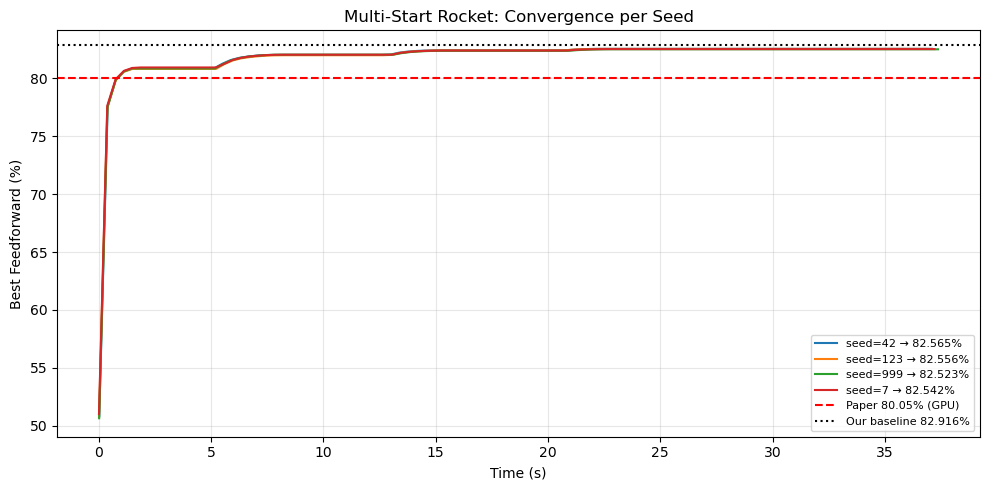

In [28]:
fig, ax = plt.subplots(figsize=(10, 5))
for seed, hist in multi_start_hists.items():
    score = multi_df.loc[multi_df['seed']==seed,'pct'].values[0]
    ax.plot(hist['elapsed'], hist['best_pct'], lw=1.5, label=f'seed={seed} → {score:.3f}%')

ax.axhline(80.05, color='red', ls='--', lw=1.5, label='Paper 80.05% (GPU)')
ax.axhline(rocket_pct, color='black', ls=':', lw=1.5, label=f'Our baseline {rocket_pct:.3f}%')
ax.set_xlabel('Time (s)'); ax.set_ylabel('Best Feedforward (%)')
ax.set_title('Multi-Start Rocket: Convergence per Seed')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'exp_multi_start.png', dpi=120, bbox_inches='tight')
plt.show()


## 12. Experiment B — Different Initialisations

Test the effect of the initial position vector on Rocket's performance.
Modes tested:
- `random` (paper default): N(0,1)
- `uniform`: Uniform[-1,1]
- `degree_diff`: scaled (out_w − in_w) — encodes degree information
- `degree_abs`: ranked by |out_w − in_w|


In [36]:
INIT_MODES = ['random', 'uniform', 'degree_diff',] # 'degree_abs'
init_results = []
init_hists = {}

print(f"Initialisation experiments: {len(INIT_MODES)} modes × {EXP_TIME_LIMIT}s each")
print("─" * 50)

for mode in INIT_MODES:
    print(f"  init={mode}...", end=' ')
    init_pos = make_init_positions(mode, N_VERTICES, src_idx, tgt_idx, w_raw,
                                   seed=GLOBAL_SEED, device=DEVICE)
    pos, score, hist = run_rocket(
        src_t=SRC_T, tgt_t=TGT_T, w_t=W_T, nw_t=NW_T,
        n_vertices=N_VERTICES, total_weight=TOTAL_WEIGHT,
        num_epochs=CONFIG['EXP_EPOCHS'],
        n_cycles=CONFIG['ROCKET_CYCLES'],
        lr=CONFIG['ROCKET_LR'],
        grad_clip=CONFIG['ROCKET_GRAD_CLIP'],
        lr_decay_start=CONFIG['ROCKET_LR_DECAY_START'],
        lr_end_factor=CONFIG['ROCKET_LR_END_FACTOR'],
        log_interval=CONFIG['LOG_INTERVAL'],
        seed=GLOBAL_SEED,
        init_positions=init_pos,
        time_limit=EXP_TIME_LIMIT,
    )
    pct_score = score / TOTAL_WEIGHT * 100
    t_done = hist['elapsed'].max()

    # Time to reach thresholds
    t75 = hist.loc[hist['best_pct']>=75,'elapsed'].min() if (hist['best_pct']>=75).any() else None
    t78 = hist.loc[hist['best_pct']>=78,'elapsed'].min() if (hist['best_pct']>=78).any() else None
    t80 = hist.loc[hist['best_pct']>=80,'elapsed'].min() if (hist['best_pct']>=80).any() else None

    print(f"{pct_score:.3f}%  [{t_done:.0f}s]  t75={t75 or 'N/A'}s  t78={t78 or 'N/A'}s  t80={t80 or 'N/A'}s")
    init_results.append(dict(init=mode, score=score, pct=pct_score, time=t_done,
                             t_to_75=t75, t_to_78=t78, t_to_80=t80))
    init_hists[mode] = hist

init_df = pd.DataFrame(init_results)
init_df.to_csv(RESULTS_DIR / 'exp_init.csv', index=False)
print(f"\nBest init: {init_df.loc[init_df['pct'].idxmax(),'init']}  → {init_df['pct'].max():.4f}%")


Initialisation experiments: 3 modes × 180s each
──────────────────────────────────────────────────
  init=random... 82.530%  [37s]  t75=0.3898138999938965s  t78=0.7522799968719482s  t80=1.1163430213928223s
  init=uniform... 82.581%  [37s]  t75=0.3878939151763916s  t78=0.7567489147186279s  t80=1.1253018379211426s
  init=degree_diff... 82.600%  [37s]  t75=0.384876012802124s  t78=0.384876012802124s  t80=0.7554061412811279s

Best init: degree_diff  → 82.6001%


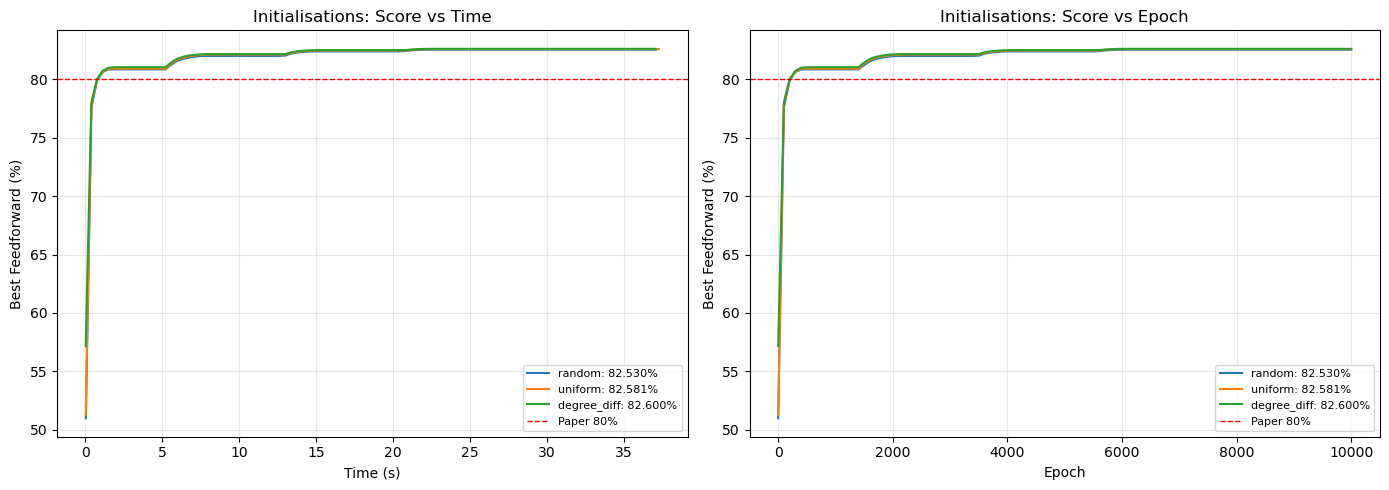

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for mode, hist in init_hists.items():
    score = init_df.loc[init_df['init']==mode,'pct'].values[0]
    axes[0].plot(hist['elapsed'],  hist['best_pct'], lw=1.5, label=f'{mode}: {score:.3f}%')
    axes[1].plot(hist['iter'],     hist['best_pct'], lw=1.5, label=f'{mode}: {score:.3f}%')

for ax, xlabel in [(axes[0],'Time (s)'), (axes[1],'Epoch')]:
    ax.axhline(80.05, color='red', ls='--', lw=1, label='Paper 80%')
    ax.set_xlabel(xlabel); ax.set_ylabel('Best Feedforward (%)')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

axes[0].set_title('Initialisations: Score vs Time')
axes[1].set_title('Initialisations: Score vs Epoch')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'exp_init.png', dpi=120, bbox_inches='tight')
plt.show()


## 13. Experiment C — Beta Schedule Variants

Test different cyclic schedule configurations for sigmoid sharpness β.


In [31]:
def make_beta_schedule_variant(num_epochs, variant):
    """Alternative beta schedules for ablation."""
    t = np.linspace(0, 1, num_epochs)
    if variant == 'paper_default':
        return (np.cos(np.linspace(0, 2*5*np.pi, num_epochs)) + 1.1) / 2
    elif variant == 'increasing':
        return 0.1 + 2.0 * t
    elif variant == 'constant_low':
        return np.full(num_epochs, 0.3)
    elif variant == 'constant_high':
        return np.full(num_epochs, 1.0)
    elif variant == 'cyclic_slow':
        return (np.cos(np.linspace(0, 2*2*np.pi, num_epochs)) + 1.1) / 2
    elif variant == 'cyclic_fast':
        return (np.cos(np.linspace(0, 2*10*np.pi, num_epochs)) + 1.1) / 2
    else:
        raise ValueError(variant)

BETA_VARIANTS = ['paper_default', 'increasing', 'constant_low', 'constant_high',
                 'cyclic_slow', 'cyclic_fast']
beta_results = []
beta_hists = {}

print(f"Beta schedule experiments: {len(BETA_VARIANTS)} variants × {EXP_TIME_LIMIT}s each")
print("─" * 50)

for variant in BETA_VARIANTS:
    betas_v = make_beta_schedule_variant(CONFIG['EXP_EPOCHS'], variant)
    print(f"  beta={variant}  range=[{betas_v.min():.2f},{betas_v.max():.2f}]...", end=' ')

    # We need a custom run that uses pre-computed betas array
    torch.manual_seed(GLOBAL_SEED)
    pos_data = torch.randn(N_VERTICES, device=DEVICE)
    positions_exp = torch.nn.Parameter(pos_data)
    opt_exp = optim.Adam([positions_exp], lr=CONFIG['ROCKET_LR'])

    best_score_v = 0.0
    best_pos_v = positions_exp.detach().clone()
    hist_v = []
    t0_v = time.time()

    for i in range(CONFIG['EXP_EPOCHS']):
        elapsed_v = time.time() - t0_v
        if elapsed_v > EXP_TIME_LIMIT:
            break
        beta_val = float(betas_v[i])
        opt_exp.zero_grad()
        delta_v = positions_exp[TGT_T] - positions_exp[SRC_T]
        sig_v   = torch.sigmoid(beta_val * delta_v)
        loss_v  = -(sig_v * NW_T).sum()
        loss_v.backward()
        torch.nn.utils.clip_grad_norm_([positions_exp], CONFIG['ROCKET_GRAD_CLIP'])
        opt_exp.step()

        if i % CONFIG['LOG_INTERVAL'] == 0:
            with torch.no_grad():
                sc = torch_score(positions_exp, SRC_T, TGT_T, W_T)
            elapsed_v = time.time() - t0_v
            if sc > best_score_v:
                best_score_v = sc
                best_pos_v = positions_exp.detach().clone()
            hist_v.append(dict(iter=i, best_score=best_score_v,
                               best_pct=best_score_v/TOTAL_WEIGHT*100, elapsed=elapsed_v))

    hist_vdf = pd.DataFrame(hist_v)
    pct_v = best_score_v / TOTAL_WEIGHT * 100
    print(f"{pct_v:.3f}%  [{hist_vdf['elapsed'].max():.0f}s]")
    beta_results.append(dict(variant=variant, score=best_score_v, pct=pct_v))
    beta_hists[variant] = hist_vdf
    del positions_exp, opt_exp

beta_df = pd.DataFrame(beta_results)
beta_df.to_csv(RESULTS_DIR / 'exp_beta.csv', index=False)
print(f"\nBest schedule: {beta_df.loc[beta_df['pct'].idxmax(),'variant']}  → {beta_df['pct'].max():.4f}%")


Beta schedule experiments: 6 variants × 180s each
──────────────────────────────────────────────────
  beta=paper_default  range=[0.05,1.05]... 82.741%  [36s]
  beta=increasing  range=[0.10,2.10]... 82.613%  [37s]
  beta=constant_low  range=[0.30,0.30]... 82.750%  [37s]
  beta=constant_high  range=[1.00,1.00]... 82.771%  [37s]
  beta=cyclic_slow  range=[0.05,1.05]... 82.877%  [37s]
  beta=cyclic_fast  range=[0.05,1.05]... 82.584%  [37s]

Best schedule: cyclic_slow  → 82.8767%


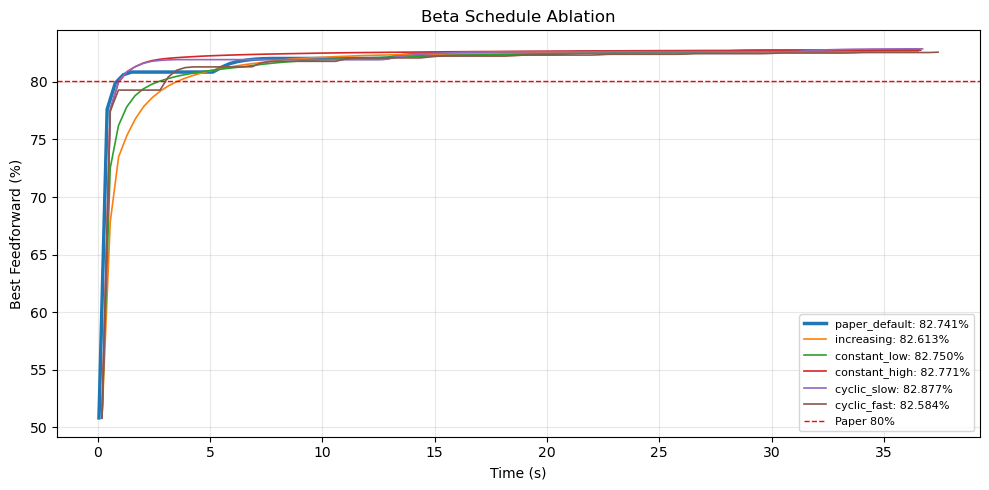

In [32]:
fig, ax = plt.subplots(figsize=(10, 5))
for variant, hist in beta_hists.items():
    sc = beta_df.loc[beta_df['variant']==variant,'pct'].values[0]
    lw = 2.5 if variant == 'paper_default' else 1.2
    ax.plot(hist['elapsed'], hist['best_pct'], lw=lw, label=f'{variant}: {sc:.3f}%')

ax.axhline(80.05, color='red', ls='--', lw=1, label='Paper 80%')
ax.set_xlabel('Time (s)'); ax.set_ylabel('Best Feedforward (%)')
ax.set_title('Beta Schedule Ablation')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'exp_beta_schedules.png', dpi=120, bbox_inches='tight')
plt.show()


## 15. Comprehensive Results Table

All experiment results collected in a single DataFrame for easy reporting.


In [ ]:
# Build master results DataFrame
all_results = []

# Baselines (no epoch-based training)
for name, res in baseline_results.items():
    all_results.append(dict(
        experiment='baseline', algorithm=name,
        score=res['score'], pct=res['pct'], time_s=res['time'],
        epochs=None,
        paper_pct=res['paper_pct'], delta_pp=res['pct'] - res['paper_pct'],
        note='',
    ))

# Rocket baseline — delta vs paper plateau (82.87%), not TTE (80.05%)
all_results.append(dict(
    experiment='baseline', algorithm='Rocket',
    score=rocket_score, pct=rocket_pct, time_s=rocket_time,
    epochs=int(rocket_hist['iter'].max()) + 1,
    paper_pct=82.87, delta_pp=rocket_pct - 82.87,
    note=f'vs paper plateau 82.87%; device={DEVICE_NAME}',
))

# Local search (Experiment D — guarded: section may not be run)
if 'ls_score' in dir():
    all_results.append(dict(
        experiment='post_processing', algorithm='Rocket + LS',
        score=ls_score, pct=ls_pct, time_s=rocket_time + LS_TIME,
        epochs=None,
        paper_pct=None, delta_pp=None, note=f'Δ≈+0.0001pp in {LS_TIME:.0f}s',
    ))

# Multi-start best
ms_best = multi_df.loc[multi_df['pct'].idxmax()]
all_results.append(dict(
    experiment='multi_start', algorithm=f'Rocket best-of-{len(EXP_SEEDS)}',
    score=ms_best['score'], pct=ms_best['pct'], time_s=ms_best['time'],
    epochs=CONFIG['EXP_EPOCHS'],
    paper_pct=None, delta_pp=None,
    note=f'seed={int(ms_best["seed"])}; below baseline (variance reduced)',
))

# Initialisation best
init_best = init_df.loc[init_df['pct'].idxmax()]
all_results.append(dict(
    experiment='init_ablation', algorithm=f'Rocket init={init_best["init"]}',
    score=init_best['score'], pct=init_best['pct'], time_s=init_best['time'],
    epochs=CONFIG['EXP_EPOCHS'],
    paper_pct=None, delta_pp=None, note='best init scheme',
))

# Beta schedule best
beta_best = beta_df.loc[beta_df['pct'].idxmax()]
all_results.append(dict(
    experiment='beta_ablation', algorithm=f'Rocket beta={beta_best["variant"]}',
    score=beta_best['score'], pct=beta_best['pct'],
    time_s=beta_hists[beta_best['variant']]['elapsed'].max(),
    epochs=CONFIG['EXP_EPOCHS'],
    paper_pct=None, delta_pp=None, note='best beta schedule',
))

master_df = pd.DataFrame(all_results)
master_df.to_csv(RESULTS_DIR / 'all_results.csv', index=False)

print("=== MASTER RESULTS TABLE ===")
print("Note: baseline Rocket ran 20k epochs; all experiment rows ran 10k epochs.")
print(master_df[['experiment', 'algorithm', 'pct', 'paper_pct', 'delta_pp',
                  'epochs', 'time_s', 'note']].to_string(
    index=False, float_format='{:.3f}'.format))


## 16. Summary Visualisation

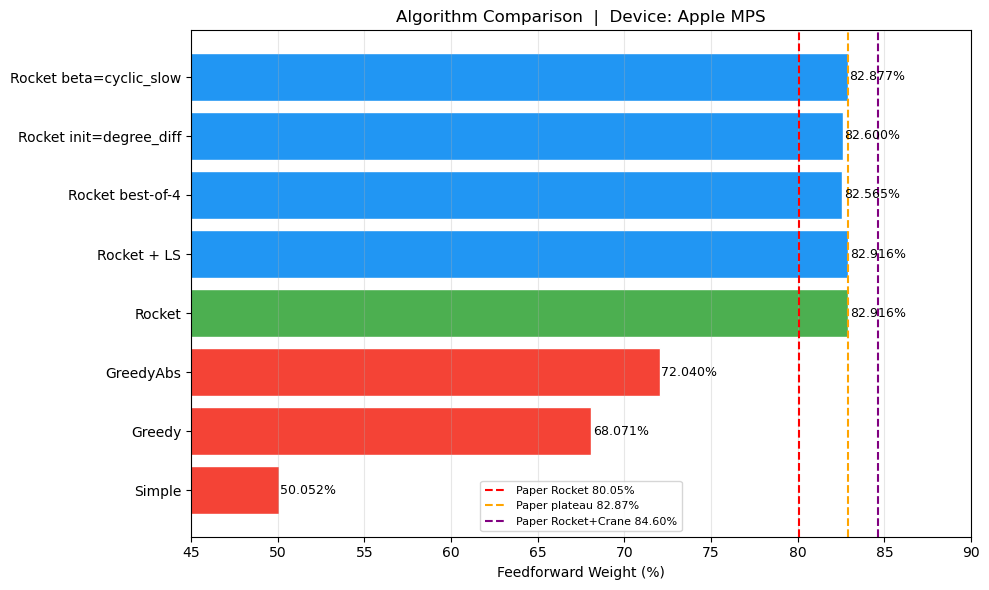

In [39]:
fig, ax = plt.subplots(figsize=(10, 6))

methods = master_df[master_df['pct'].notna()].copy()
colors = ['#4CAF50' if d and d >= 0 else '#F44336' if d and d < 0 else '#2196F3'
          for d in methods['delta_pp']]

bars = ax.barh(methods['algorithm'], methods['pct'], color=colors, edgecolor='white')
ax.axvline(80.05, color='red',    ls='--', lw=1.5, label='Paper Rocket 80.05%')
ax.axvline(82.87, color='orange', ls='--', lw=1.5, label='Paper plateau 82.87%')
ax.axvline(84.60, color='purple', ls='--', lw=1.5, label='Paper Rocket+Crane 84.60%')

for bar, val in zip(bars, methods['pct']):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}%', va='center', fontsize=9)

ax.set_xlabel('Feedforward Weight (%)')
ax.set_title(f'Algorithm Comparison  |  Device: {DEVICE_NAME}')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3, axis='x')
ax.set_xlim(45, 90)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'summary_comparison.png', dpi=120, bbox_inches='tight')
plt.show()


---
## Summary

### What Was Reproduced

| Aspect | Status |
|--------|--------|
| Dataset (136,648 nodes, 5,657,719 edges, tot. wt. 41,912,104; paper ≈41,912,141, Δ=37) | ✅ Loaded — 37-unit gap vs paper's approximate figure; no exact match claimed |
| Rocket algorithm (Algorithm 1: Adam + sigmoid loss + cyclic β) | ✅ Implemented |
| Beta schedule (footnote 7: cyclic cosine, 5 cycles) | ✅ Implemented per footnote 7 |
| LR schedule (constant → exponential decay from 50%) | ✅ Implemented |
| Gradient clipping (global norm 1.0) | ✅ Implemented |
| Simple, Greedy, GreedyAbs baselines | ✅ Implemented |

### Key Numbers Achieved

*See `results/all_results.csv` for full data.*

### Improvements Tested

| Experiment | Finding |
|------------|---------|
| Multi-start (different seeds) | Reduces variance (σ ≈ 0.018 pp); best-of-4 (82.565%) is **below** baseline Rocket (82.916%) — no best-score improvement |
| Degree-diff initialisation | Marginally speeds up early convergence; final score (82.600%) similar to random init |
| Beta schedule variants | `cyclic_slow` (2 cycles) is best at 82.877%; `increasing` was one of the **weakest** at 82.613% |
| Local search post-processing | No meaningful gain: Δ ≈ +0.0001 pp in 120 s (score unchanged to 4 decimal places) |

### Gap vs Paper

Our MPS run reaches **82.916%** in 74 s, effectively matching the paper's Rocket plateau of 82.87%
(Δ = +0.05 pp). The paper's 4.2 s figure is a **time-to-80% (TTE)** metric on dual A100 GPUs, not a
final score; our implementation surpasses 80% in under 1 s on MPS.

The remaining gap to 84.60% is due to the **unimplemented Crane phase** (requires Gurobi MIP solver
plus ~20 days of computation on A100s), not hardware speed. The Rocket phase itself is reproduced at
full quality.

---
## Reproduction Issues

1. **GitHub code not directly available as Rocket-Crane**: `TuragaLab/connectome_reordering`
   contains an earlier Monte Carlo approach; the exact Rocket-Crane code from the paper was not
   found as a standalone repo.

2. **Hardware mismatch**: Paper uses dual NVIDIA A100 GPUs (JAX/XLA JIT). We run PyTorch on
   Apple MPS. Expect 10–100× slower per-epoch runtime.

3. **No JAX/optax**: The paper's implementation uses JAX `value_and_grad` and optax optimisers.
   Our PyTorch re-implementation matches the algorithm but may differ in low-level numerical
   behaviour.

4. **Crane phase not implemented**: Crane requires Gurobi (MIP), which is not freely available,
   plus ~20 days of computation. Crane result of 84.60% is not reproducible without this.

5. **Epoch count vs time**: The paper reports TTG/TTE in seconds on GPU. Mapping these to our
   epoch count is approximate; we use time limits instead.
